In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import firedrake
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask

%matplotlib widget

In [2]:
# Fine DEM

src_bed_fine = rasterio.open("../Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif")
src_surf_fine = rasterio.open("../Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif")

# Course DEM

src_bed_coarse = rasterio.open("../Meshes/ThreeD_meshing/bedmachine_ian_merged_bed_large_aoi_8m_aligned_fixed.tif")
src_surf_coarse = rasterio.open("../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif")

### Load the outline of the good dem

with rasterio.open('../Meshes/good_dem_outline/ian_bed_outline_raster_full.tif') as src_good_dem:
    good_dem_filter = src_good_dem.read(2)

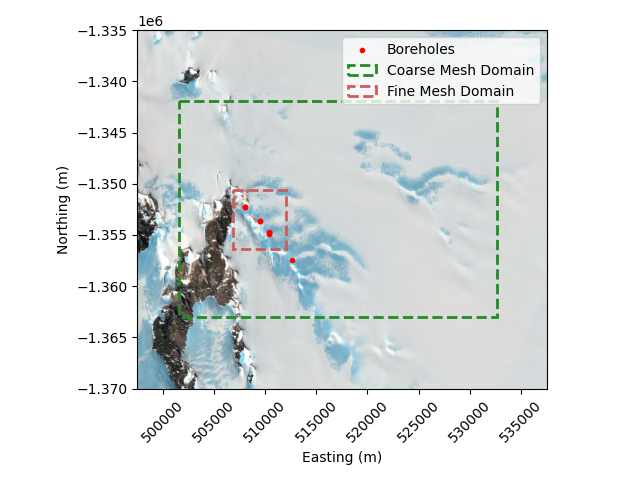

In [3]:
# Load tiff files of the DEMs

### Load boreholes
borehole_locations = pd.read_csv('../Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])

### Load image data

with rasterio.open('../imagery/LIMA_virtual_Mosaic_15m.tif') as src1:
    image_data = src1.read()

### Load the GPS velocities
gps_velocities = pd.read_csv('../GPS_velocities/24-25_velocities-good.csv')

fig, ax = plt.subplots()

ax.scatter(transformed_x,transformed_y, marker='.',c='red', label='Boreholes')
show(image_data,ax=ax,transform=src1.transform)

for src_bed, src_surf, upscale_factor, name in [[src_bed_coarse, src_surf_coarse, 1/100, 'Coarse Mesh Domain'], 
                                                [src_bed_fine, src_surf_fine, 1/12, 'Fine Mesh Domain']]:


    bed_DEM = src_bed.read(1,
                            out_shape=(
                                src_bed.count,
                                int(src_bed.height * upscale_factor),
                                int(src_bed.width * upscale_factor)
                            ),
                            resampling=Resampling.bilinear
                        )

    # scale image transform
    src_bed_transform = src_bed.transform * src_bed.transform.scale(
        (src_bed.width / bed_DEM.shape[-1]),
        (src_bed.height / bed_DEM.shape[-2])
    )


    # src_surf = rasterio.open("../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif")

    surf_DEM = src_surf.read(1,
                            out_shape=(
                                src_surf.count,
                                int(src_surf.height * upscale_factor),
                                int(src_surf.width * upscale_factor)
                            ),
                            resampling=Resampling.bilinear
                        )

    # scale image transform
    src_surf_transform = src_surf.transform * src_surf.transform.scale(
        (src_surf.width / surf_DEM.shape[-1]),
        (src_surf.height / surf_DEM.shape[-2])
    )

    ### Check if the bed DEMs is higher than the surface DEM (thickness is negative) ###


    thickness = surf_DEM - bed_DEM
    thickness[thickness > 0] = 0  # if positive, set to 0. This will mask the negative thickness values
    zero_offset = copy.deepcopy(thickness)
    zero_offset[zero_offset < 0 ] = -1 # this mask will lower the bed a further 1m in the areas where thickness is negative so the model doesn't crash on a zero.
    bed_DEM = bed_DEM + thickness + zero_offset # add the negative values to the bed to push it lower to match the surface DEM



    height = surf_DEM.shape[0]
    width = surf_DEM.shape[1]
    cols, rows = np.meshgrid(np.arange(width), np.arange(height))
    xs, ys = rasterio.transform.xy(src_surf_transform, rows, cols)
    lons= np.array(xs)
    lats = np.array(ys)

    surf_elevs = surf_DEM.flatten()
    bed_elevs = bed_DEM.flatten()

    # ax = plt.figure(figsize=[10,5]).add_subplot(projection='3d')

    # ax.scatter(lons, lats, bed_elevs, label="Bed DEM")
    # ax.scatter(lons, lats, surf_elevs, label="Surface DEM")

    # ax.set_xlabel('Easting (m)')
    # ax.set_ylabel('Northing (m)')
    # ax.set_zlabel('Elevation (m)')


    # ax.legend()

    # plt.tight_layout()

    # plt.savefig('DEM_coarse_3D_view.png', dpi=300, transparent=True)






    width_m = src_surf_transform[0] *surf_DEM.shape[1]
    height_m = src_surf_transform[4] *surf_DEM.shape[0]
    if name == "Coarse Mesh Domain":
        ax.add_patch(plt.Rectangle((src_surf_transform[2], src_surf_transform[5]),width_m,height_m,  ls='--', lw = 2, ec='forestgreen',fc='None', label=name))
    if name == "Fine Mesh Domain":
        ax.add_patch(plt.Rectangle((src_surf_transform[2], src_surf_transform[5]),width_m,height_m,  ls='--', lw = 2, ec='indianred',fc='None', label=name))


    # GPS_points = []
    # for i in gps_velocities.iloc():
    #     GPS_points.append([i['x'], i['y']])
    # # ax.quiver(gps_velocities['x'], gps_velocities['y'], 
    # #                 gps_velocities['u'], gps_velocities['v'], 
    # #                 scale = None, label='GPS velocities')

ax.set_xlim([4.975e5, 5.375e5])
ax.set_ylim([-1.37e6, -1.335e6])

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()
plt.show()

# plt.savefig('mesh_domains_on_imagery.png', dpi=300, transparent=True)

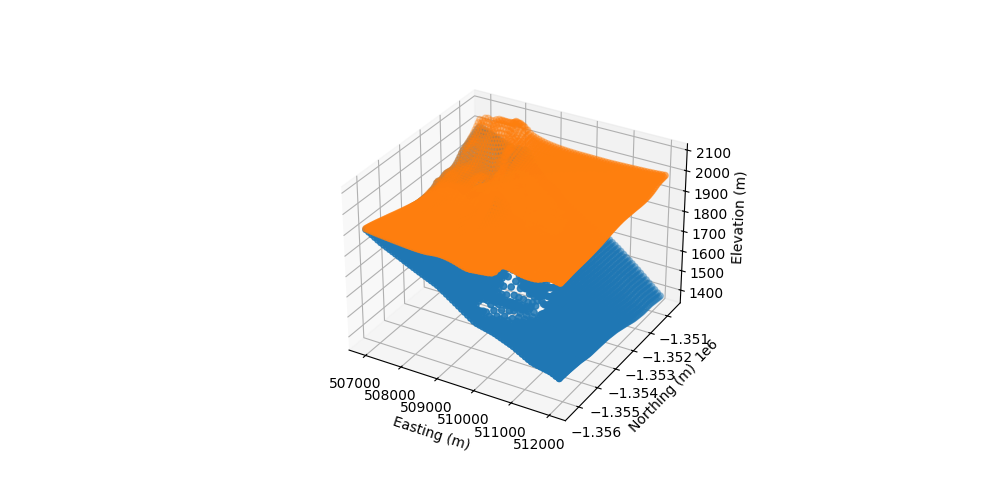

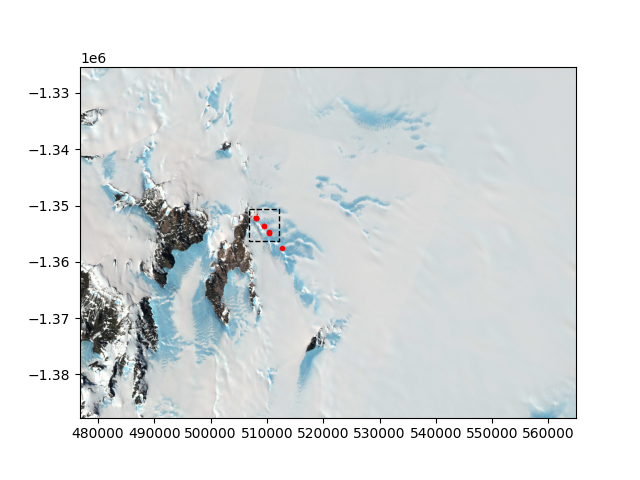

In [4]:
# Load tiff files of the DEMs

src_bed = src_bed_fine
src_surf = src_surf_fine

upscale_factor = 1/10


bed_DEM = src_bed.read(1,
                        out_shape=(
                            src_bed.count,
                            int(src_bed.height * upscale_factor),
                            int(src_bed.width * upscale_factor)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_bed_transform = src_bed.transform * src_bed.transform.scale(
    (src_bed.width / bed_DEM.shape[-1]),
    (src_bed.height / bed_DEM.shape[-2])
)


# src_surf = rasterio.open("../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif")

surf_DEM = src_surf.read(1,
                        out_shape=(
                            src_surf.count,
                            int(src_surf.height * upscale_factor),
                            int(src_surf.width * upscale_factor)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_surf_transform = src_surf.transform * src_surf.transform.scale(
    (src_surf.width / surf_DEM.shape[-1]),
    (src_surf.height / surf_DEM.shape[-2])
)

### Check if the bed DEMs is higher than the surface DEM (thickness is negative) ###


thickness = surf_DEM - bed_DEM
thickness[thickness > 0] = 0  # if positive, set to 0. This will mask the negative thickness values
zero_offset = copy.deepcopy(thickness)
zero_offset[zero_offset < 0 ] = -1 # this mask will lower the bed a further 1m in the areas where thickness is negative so the model doesn't crash on a zero.
bed_DEM = bed_DEM + thickness + zero_offset # add the negative values to the bed to push it lower to match the surface DEM



# surf_DEM[surf_DEM==0] = 2000 
# bed_DEM[bed_DEM==-1] = 1999
## Downsample the DEMs if desired
# downsample_factor = 20
# surf_DEM = surf_DEM[::downsample_factor, ::downsample_factor]
# bed_DEM = bed_DEM[::downsample_factor, ::downsample_factor]

height = surf_DEM.shape[0]
width = surf_DEM.shape[1]
cols, rows = np.meshgrid(np.arange(width), np.arange(height))
xs, ys = rasterio.transform.xy(src_surf_transform, rows, cols)
lons= np.array(xs)
lats = np.array(ys)

surf_elevs = surf_DEM.flatten()
bed_elevs = bed_DEM.flatten()

ax = plt.figure(figsize=[10,5]).add_subplot(projection='3d')

ax.scatter(lons, lats, bed_elevs)
ax.scatter(lons, lats, surf_elevs)

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_zlabel('Elevation (m)')

### Load boreholes
borehole_locations = pd.read_csv('../Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])

### Load image data

with rasterio.open('../imagery/LIMA_virtual_Mosaic_15m.tif') as src1:
    image_data = src1.read()

fig, ax = plt.subplots()
ax.scatter(transformed_x,transformed_y, marker='.',c='red', label='Boreholes')
show(image_data,ax=ax,transform=src1.transform)

width_m = src_surf_transform[0] *surf_DEM.shape[1]
height_m = src_surf_transform[4] *surf_DEM.shape[0]

ax.add_patch(plt.Rectangle((src_surf_transform[2], src_surf_transform[5]),width_m,height_m,  ls='--', ec='black',fc='None'))

### Load the GPS velocities
gps_velocities = pd.read_csv('../GPS_velocities/24-25_velocities-good.csv')

